# Сегментация посетителей фитнес-клуба

**Цель:** выявить поведенческие сегменты клиентов 
для персонализации маркетинга и снижения оттока.

**Данные:** Gym Members Exercise Dataset, 973 записи, 15 признаков.

## Содержание
- [1. Загрузка данных](#1-загрузка-данных)
- [2. EDA](#2-eda)
- [3. Preprocessing](#3-preprocessing)
- [4. Кластеризация](#4-кластеризация)
- [5. Выводы](#5-выводы)

In [239]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Загрузка данных

In [240]:
df = pd.read_csv('../data/gym_members_exercise_tracking.csv')
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## 2. EDA

In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [242]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


Проверка пропусков

In [243]:
df.isna().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

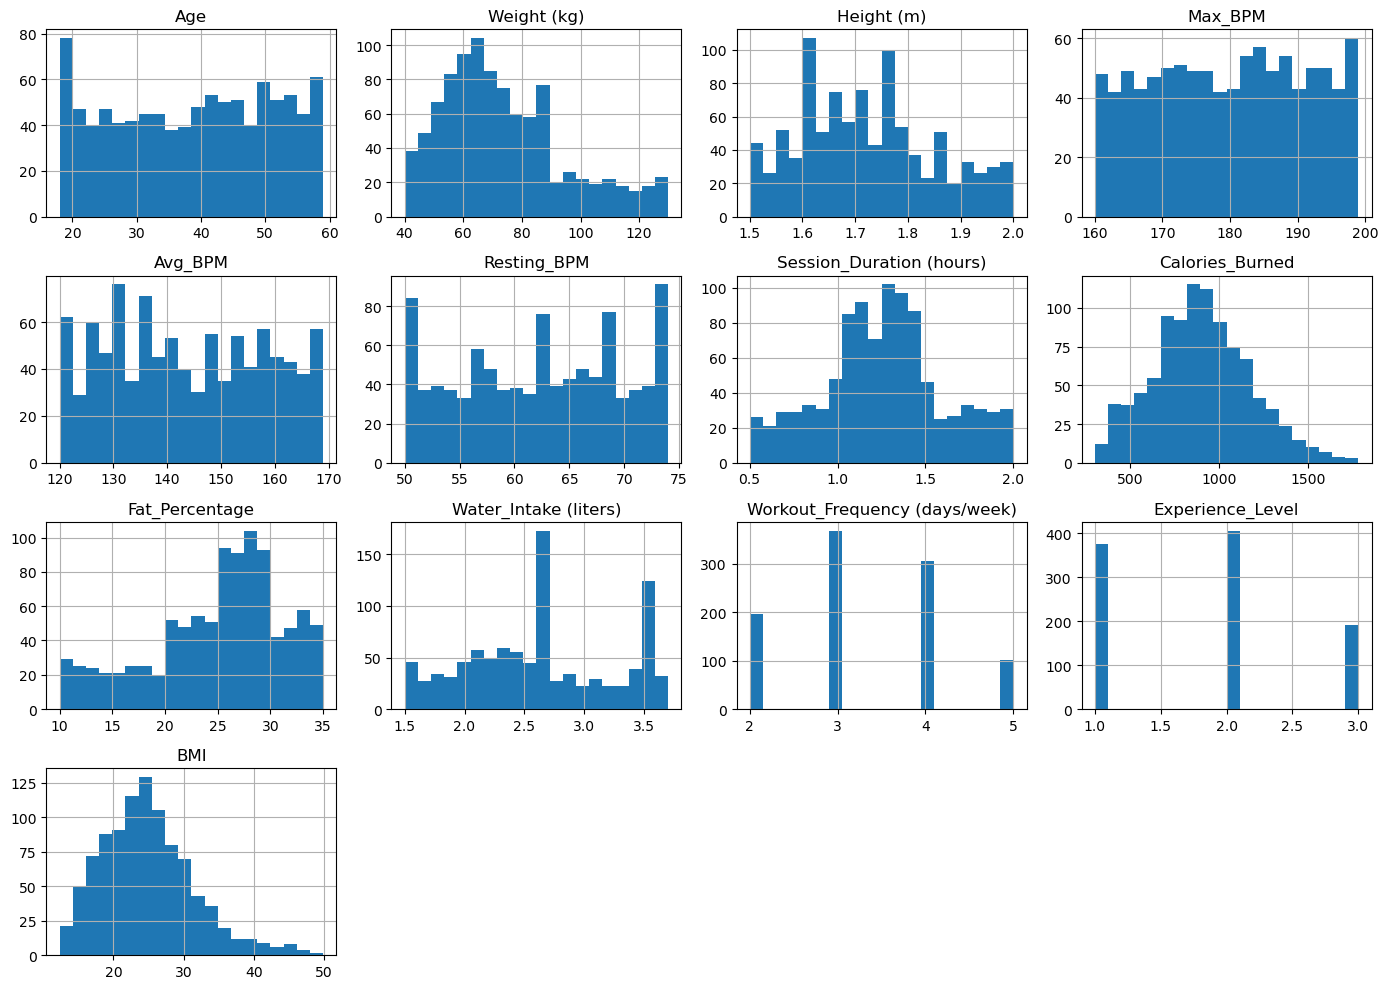

In [244]:
df.hist(figsize = (14, 10), bins = 20)
plt.tight_layout()
plt.show()

In [245]:
print(df['Gender'].value_counts())
print(df['Workout_Type'].value_counts())
print(df['Experience_Level'].value_counts())

Gender
Male      511
Female    462
Name: count, dtype: int64
Workout_Type
Strength    258
Cardio      255
Yoga        239
HIIT        221
Name: count, dtype: int64
Experience_Level
2    406
1    376
3    191
Name: count, dtype: int64


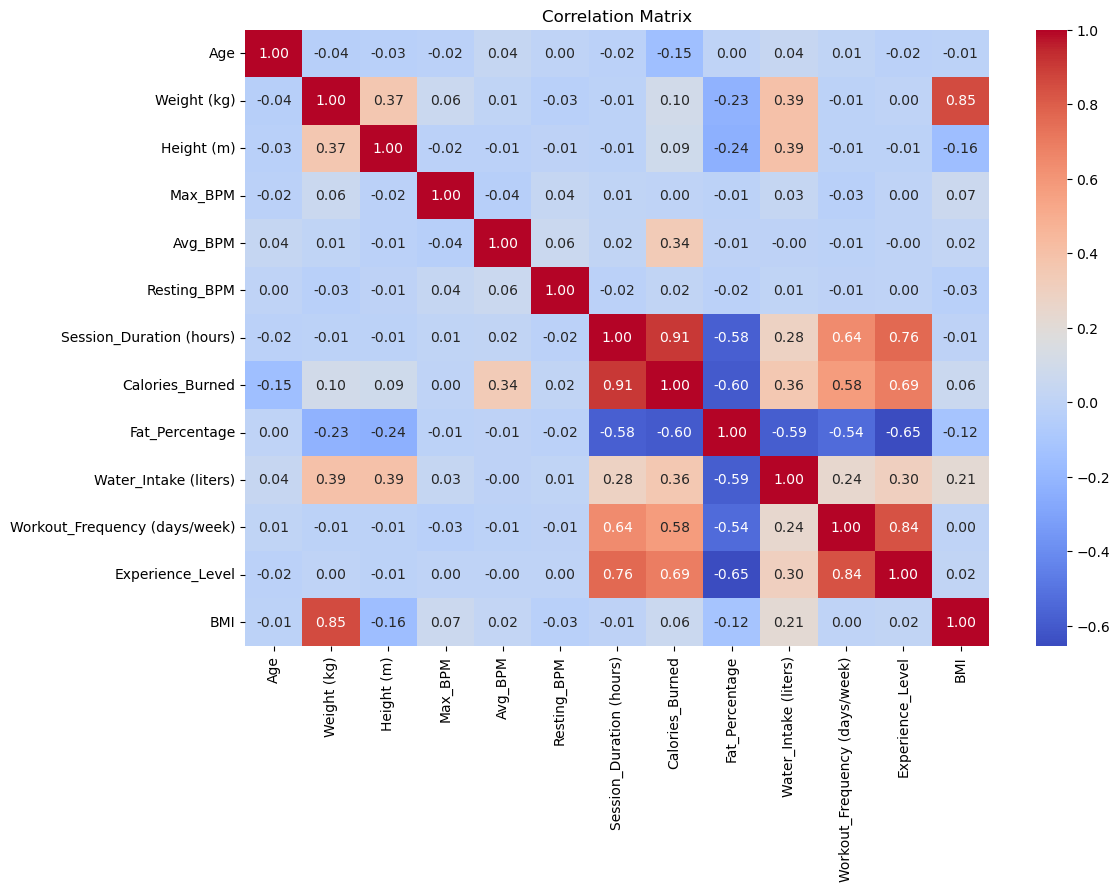

In [246]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [247]:
df.corr(numeric_only=True)

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
Age,1.000000,-0.036340,-0.027837,-0.017073,0.035969,0.004354,-0.019912,-0.154679,0.002370,0.041528,0.008055,-0.018676,-0.013691
Weight (kg),-0.036340,1.000000,0.365321,0.057061,0.009717,-0.032138,-0.013666,0.095443,-0.225512,0.394276,-0.011769,0.003379,0.853158
Height (m),-0.027837,0.365321,1.000000,-0.017660,-0.014776,-0.005090,-0.010206,0.086348,-0.235521,0.393533,-0.011270,-0.010267,-0.159469
Max_BPM,-0.017073,0.057061,-0.017660,1.000000,-0.039751,0.036647,0.010051,0.002090,-0.009056,0.031621,-0.029099,0.000545,0.067105
Avg_BPM,0.035969,0.009717,-0.014776,-0.039751,1.000000,0.059636,0.016014,0.339659,-0.007302,-0.002911,-0.010681,-0.000888,0.021605
Resting_BPM,0.004354,-0.032138,-0.005090,0.036647,0.059636,1.000000,-0.016649,0.016518,-0.016834,0.007726,-0.007967,0.001758,-0.032543
Session_Duration (hours),-0.019912,-0.013666,-0.010206,0.010051,0.016014,-0.016649,1.000000,0.908140,-0.581520,0.283411,0.644140,0.764768,-0.006493
Calories_Burned,-0.154679,0.095443,0.086348,0.002090,0.339659,0.016518,0.908140,1.000000,-0.597615,0.356931,0.576150,0.694129,0.059761
Fat_Percentage,0.002370,-0.225512,-0.235521,-0.009056,-0.007302,-0.016834,-0.581520,-0.597615,1.000000,-0.588683,-0.537060,-0.654363,-0.119258
Water_Intake (liters),0.041528,0.394276,0.393533,0.031621,-0.002911,0.007726,0.283411,0.356931,-0.588683,1.000000,0.238563,0.304104,0.213697


In [248]:
corr_matrix = df.corr(numeric_only=True)
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) >= 0.8 :
            print(f"{cols[i]} — {cols[j]}: {corr_matrix.iloc[i, j]:.2f}")

Weight (kg) — BMI: 0.85
Session_Duration (hours) — Calories_Burned: 0.91
Workout_Frequency (days/week) — Experience_Level: 0.84


Выявлена высокая корреляция между рядом признаков, что свидетельствует
о наличии избыточной информации в данных

## 3. Preprocessing

Между Experience_Level и тренировочной активностью клиентов обнаружена сильная связь. Чтобы кластеризация не дублировала уже имеющееся разделение клиентов на группы, признак Experience_Level необходимо на время удалить. После кластеризации можно будет сравнить разделение моделью и реальными данными.

In [249]:
experience_lvl = df['Experience_Level']

Для уменьшения размерности признакового пространства принято решение удалить столбцы:
- Weight (kg);
- Height (m);
- Session_Duration;
- Workout_Frequency;
- BMI.

Удаление признаков Weight (kg), Height (m), BMI обусловлено тем, что они не описывают поведенческую активность клиентов.

In [250]:
corr_columns = ['Weight (kg)',
                'Height (m)',
                'Workout_Frequency (days/week)', 
                'Session_Duration (hours)',
                'Experience_Level',
                'BMI']

In [251]:
df = df.drop(corr_columns, axis=1)

In [252]:
df['Gender'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

df = pd.get_dummies(df, columns=['Workout_Type'], prefix='Workout', dtype=int)

In [253]:
df.head()

,Age,Gender,Max_BPM,Avg_BPM,Resting_BPM,Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Cardio,Workout_HIIT,Workout_Strength,Workout_Yoga
0,56,0,180,157,60,1313.0,12.6,3.5,0,0,0,1
1,46,1,179,151,66,883.0,33.9,2.1,0,1,0,0
2,32,1,167,122,54,677.0,33.4,2.3,1,0,0,0
3,25,0,190,164,56,532.0,28.8,2.1,0,0,1,0
4,38,0,188,158,68,556.0,29.2,2.8,0,0,1,0


In [254]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)